# Cliff Walking: Q-Learning

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [13]:
import numpy as np
np.set_printoptions(precision=2)

In [14]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.utils import print_gridworld
from gym_classics.animation import gridworld_animate
                                    
from gym_classics.algorithms import random_policy

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:83: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Cliff Walking

Example from Sutton/Barto Chapter 6.

![Clif Walking problem description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-intro_Cliffwalking.png)

Cliff Walking is a standard undiscounted,
episodic task, with start
and goal states, and the usual actions
causing movement up, down,
right, and left. Reward is −1 on all
transitions except those into the region
marked “The Cliff.” Stepping
into this region incurs a reward of
−100 and sends the agent instantly
back to the start.


The patched version of the `gym_classic` defines the environment as 'CliffWalk-v1'.

We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [15]:
gym_env = gym.make('CliffWalk-v1')
env = gym_env.unwrapped

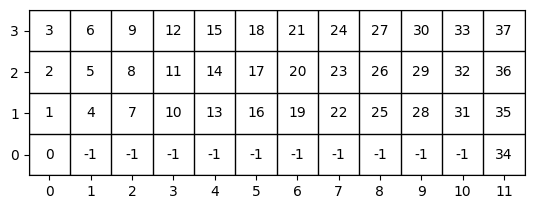

In [16]:
env.image()

## Sarsa

In [17]:
import random

# np.argmax does not break ties randomly
def random_argmax(x):
    return np.random.choice(np.where(x == np.max(x))[0])


def Sarsa(env, discount, alpha, epsilon, n = 100, verbose = False):
    Q = np.zeros((len(env.states()), len(env.actions())))
    
    for i in range(n):
        s, r = env.reset()
         
        
        if verbose:
            print ("--- New Episode ---") 
          
        if (random.random() > epsilon):
            a = random_argmax(Q[s,:])
        else:
            a = np.random.choice(env.actions())  
          
        done = False
        while not done:            
            sp, r, done, _, _ = env.step(a)
        
            if (random.random() > epsilon):
                ap = random_argmax(Q[sp,:])
            else:
                ap = np.random.choice(env.actions()) 
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * Q[sp,ap] - Q[s,a])
            
            if verbose:
                print("sarsa:", s,a,r,sp,ap, "New Q(s,a):", Q[s,a])
            
            s = sp
            a = ap
          
    return Q

In [18]:
Q = Sarsa(env, discount=1, alpha=.1, epsilon=.1, n = 10000)

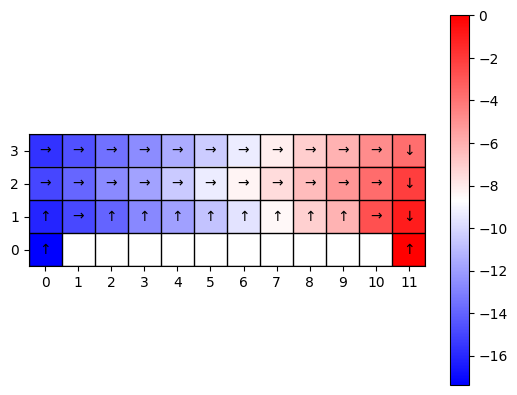

In [19]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)

In [32]:
Q = Sarsa(env, discount=1, alpha=.1, epsilon=.5, n = 10000)

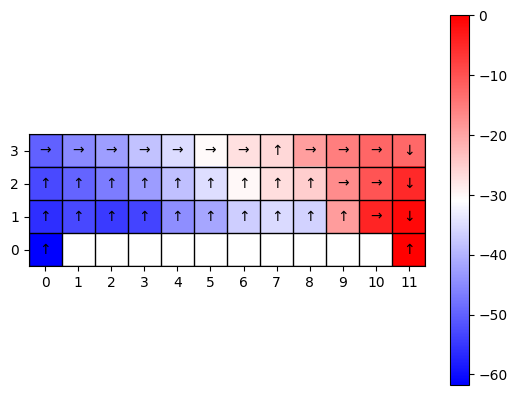

In [33]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)

**Note:** Walking along the cliff is the shortest path. However, since Sarsa is on-policy and learns an $\epsilon$-greedy policy, 
walking along the cliff is not a good idea when $\epsilon$ is large! This is why the policy sends us up to row 2 or 3 depending on $\epsilon$.

## Q-Learning

In [23]:
import random

# np.argmax does not break ties randomly
def random_argmax(x):
    return np.random.choice(np.where(x == np.max(x))[0])

def Q_learning(env, discount, alpha, epsilon, n = 100):
    Q = np.zeros((len(env.states()), len(env.actions())))
    
    for i in range(n):
        s, r = env.reset()
          
        done = False
        while not done:
            # epsilon-greedy choice w.r.t. Q 
            if (random.random() > epsilon):
                a = random_argmax(Q[s,:])
            else:
                a = np.random.choice(env.actions())
            
            sp, r, done, _, _ = env.step(a)
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * np.max(Q[sp,:]) - Q[s,a])
            
            s = sp
          
    return Q

In [24]:
Q = Q_learning(env, discount=1, alpha=.1, epsilon=.1, n = 1000)

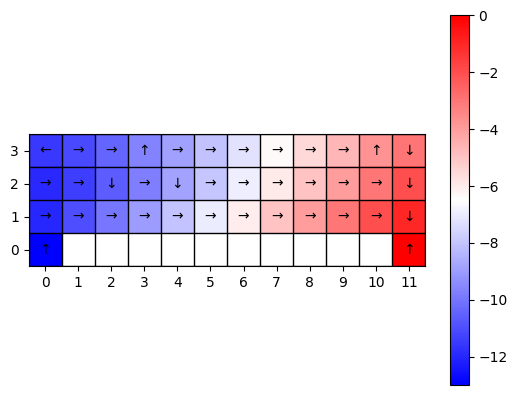

In [25]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)

In [26]:
Q = Q_learning(env, discount=1, alpha=.1, epsilon=.5, n = 1000)

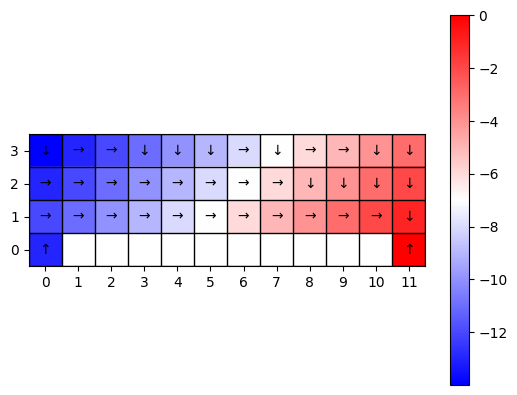

In [27]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)

**Note:** Q-Learning is off-policy and learns the optimal deterministic policy which is the shortest path along the cliff. This is not affected by
the $\epsilon$ used for the behavior policy. 


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)